# Cucker-Smale Benchmark

Goal: evaluate continuous-state MF-REINFORCE on flocking control, where the learned controller should reduce velocity disagreement without excessive control energy.

**Environment Basics**

- State space: $\mathcal{X}=\mathbb{R}^2$, with particle state $(x_i,v_i)$ for position and velocity.
- Action space: $\mathcal{A}=\mathbb{R}$, with scalar acceleration/control $u_i$; the policy mean is bounded by `a_max` and rollout exploration adds Gaussian noise.
- Population law: represented by an empirical particle law over $(x,v)$.
- Interaction: particles align through $A_i=\frac{1}{N}\sum_j \psi(|x_i-x_j|)(v_j-v_i)$ with $\psi(r)=K/(1+r^2)^\beta$.
- Dynamics: $x_{i,t+1}=x_{i,t}+\Delta t\,v_{i,t}$ and $v_{i,t+1}=v_{i,t}+\Delta t(A_i+u_i)+\sigma\sqrt{\Delta t}\xi_{i,t+1}$.
- Main task: align velocities while limiting control energy.

For particles with state $(x_i,v_i)$, the main plotted statistics are

$$
D_v(t)=\frac{1}{N}\sum_{i=1}^N |v_i(t)-\bar v_t|^2,
\qquad
D_x(t)=\max_i x_i(t)-\min_i x_i(t).
$$

The running cost used in rollouts is proportional to

$$
\Delta t\left(|v_i-\bar v_t|^2+\gamma |u_i|^2\right),
$$

so lower velocity dispersion is only meaningful when it is achieved at reasonable control cost.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from mfc.experiments import notebook_helpers as nh

ENV_NAME = "cucker-smale"
BASE_DIR = ROOT / "runs" / "extended_benchmark_bundles" / ENV_NAME
PRESET = "mid"
QUICK = PRESET == "mid"
RUN_MISSING = True
FORCE_REBUILD = False
EXTENDED = True

In [2]:
bundle = (
    nh.ensure_continuous_benchmark_bundle(ENV_NAME, BASE_DIR, quick=QUICK, force=FORCE_REBUILD, extended=EXTENDED, preset=PRESET)
    if RUN_MISSING
    else nh.continuous_bundle_paths(ENV_NAME, BASE_DIR)
)
bundle

{'env': 'cucker-smale',
 'base_dir': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/cucker-smale'),
 'train': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/cucker-smale/train/cucker-smale_continuous-mfreinforce')},
 'application': {'continuous-mfreinforce': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/cucker-smale/application/cucker-smale_continuous-mfreinforce')},
 'diagnostics': {'continuous-mfreinforce': {'perturbation': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/cucker-smale/diagnostics/cucker-smale_continuous-mfreinforce_perturbation'),
   'functional_law': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/cucker-smale/diagnostics/cucker-smale_continuous-mfreinforce_functional_law'),
   'gradient': PosixPath('/home/adonis/Internship/MFC_RL/runs/extended_benchmark_bundles/cucker-smale/diagnostics/cucker-smale_continuou

## Figure Coverage

Goal: show which requested results from `docs/figures.md` are currently produced by this notebook and which artifacts support them.

The tables are an audit layer, not an estimator. A row maps a desired result family to the command or study that generates its data and to the notebook helper that renders it.

In [3]:
nh.figure_checklist(ENV_NAME)

,figure_family,command_or_study,files,notebook_section
0,perturbation_geometry,diagnose-perturbation,"diagnostics.csv, perturbation_samples.csv",universal diagnostics
1,functional_law,diagnose-functional-law,"diagnostics.csv, signature_samples.csv, functi...",universal diagnostics
2,score_validation,score-validation,"diagnostics.csv, score_coordinates.csv, score_...",universal diagnostics
3,gradient_validation,diagnose-gradient,"diagnostics.csv, gradient_samples.csv, gradien...",universal diagnostics
4,sensitivity_validation,diagnose-sensitivity,"diagnostics.csv, sensitivity_samples.csv",universal diagnostics
5,horizon_scaling,horizon-scaling,"grid_metrics.csv, diagnostics.csv",study sweeps
6,budget_allocation,budget-allocation,"grid_metrics.csv, diagnostics.csv",study sweeps
7,particle_approximation,particle-approximation,"grid_metrics.csv, diagnostics.csv",study sweeps
8,particle_transfer,particle-transfer,"diagnostics.csv, optimization_history.csv",study sweeps
9,ablation,ablation,"grid_metrics.csv, diagnostics.csv",study sweeps


In [4]:
nh.figure_coverage_matrix(ENV_NAME)

,figure_or_result,status,notebook_helper,artifact
0,"perturbation mean, bands, and empirical slopes",ready,"plot_perturbation_geometry, plot_perturbation_...",diagnostics/*_perturbation/diagnostics.csv
1,finite-state d_TV perturbation calibration and...,ready,"perturbation_tv_comparison_table, plot_perturb...","diagnostics/*_perturbation/diagnostics.csv, di..."
2,functional-law signature summaries,ready,"plot_functional_law, plot_functional_signature...",diagnostics/*_functional_law/diagnostics.csv
3,"functional-law histograms, pair plots, Q-Q plots",ready,plot_functional_sample_diagnostics,diagnostics/*_functional_law/signature_samples...
4,"score mean, variance, lambda^2 variance, coord...",ready,"plot_score_validation, plot_score_coordinate_d...",diagnostics/*_score/*.csv
5,"gradient bias, variance, MSE, cosine, norm, de...",ready,"plot_gradient_validation, plot_gradient_error_...",diagnostics/*_gradient/diagnostics.csv
6,coordinatewise gradient scatter and CI coverage,ready,plot_gradient_coordinate_diagnostics,diagnostics/*_gradient/gradient_coordinates.cs...
7,sensitivity error vs time/eta and heatmap,ready,"plot_sensitivity_validation, plot_sensitivity_...",diagnostics/*_sensitivity/diagnostics.csv
8,budget allocation heatmap and runtime Pareto,ready,"plot_budget_and_horizon, plot_budget_pareto",studies/budget_allocation/*.csv
9,horizon scaling,ready,plot_budget_and_horizon,studies/horizon_scaling/*.csv


## Training

Goal: summarize the continuous-state MF-REINFORCE optimization trace.

The value/cost curve reports the evaluation objective at episode $k$, and the gradient-norm curve reports

$$
\|\widehat g_k\|_2,
$$

where $\widehat g_k$ is the continuous MF-REINFORCE estimator used for that parameter update.

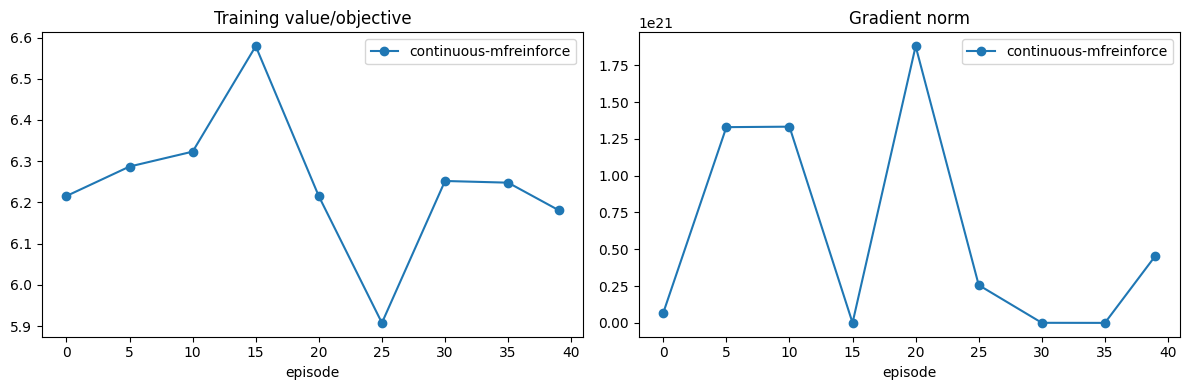

In [5]:
histories = nh.load_training_histories(bundle)
nh.plot_training_comparison(histories)

## Application Diagnostics

Goal: determine whether the learned controller produces flocking and whether alignment persists after control is removed.

Reference: application plots compare the learned controller with uncontrolled dynamics and, when configured, a grid-searched global-alignment heuristic. Gradient/sensitivity diagnostic sections use independent pathwise-AD particle references.

The main metrics are velocity dispersion $D_v(t)$, spatial diameter $D_x(t)$, and mean control energy $\frac{1}{N}\sum_i |u_i(t)|^2$. Snapshot panels show particles in phase space $(x_i,v_i)$, and post-control curves test whether the learned alignment is stable without continued intervention.

,algorithm,reference_kind,controlled_objective,free_objective,heuristic_objective,heuristic_best_kappa
0,continuous-mfreinforce,pathwise_particle_baselines,6.059989,6.233882,0.584856,1.0


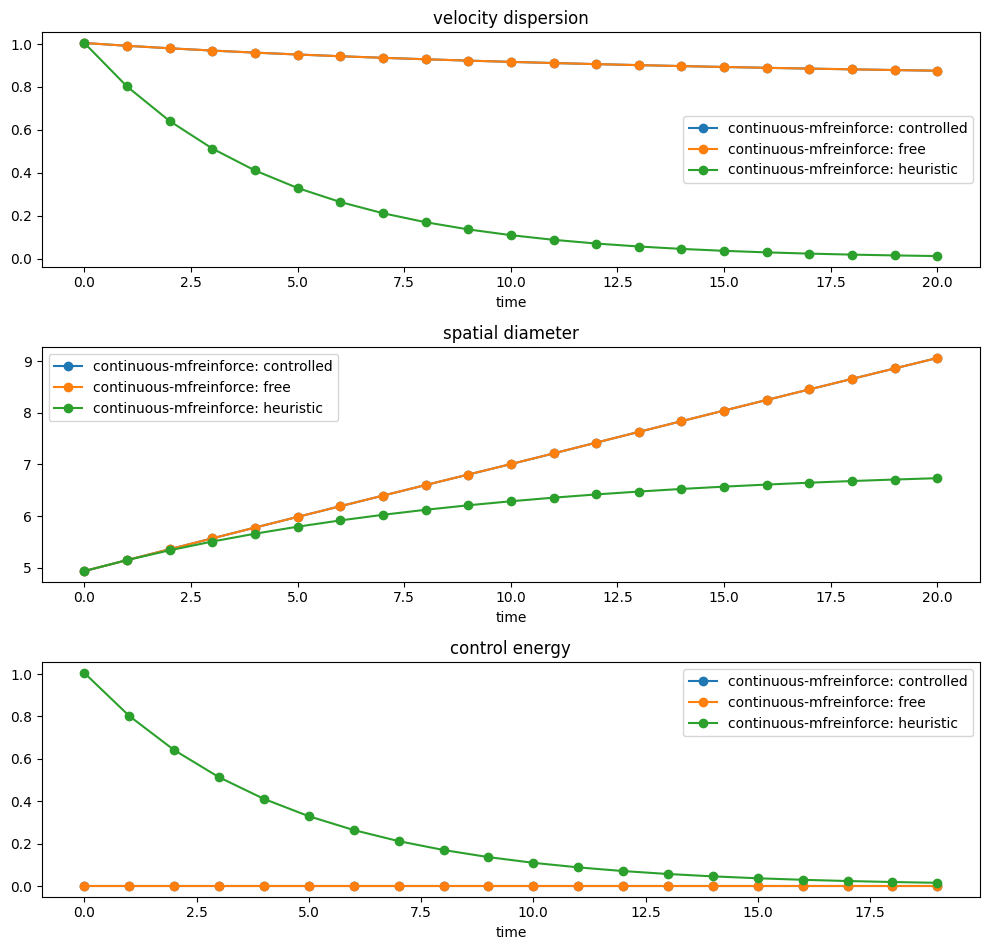

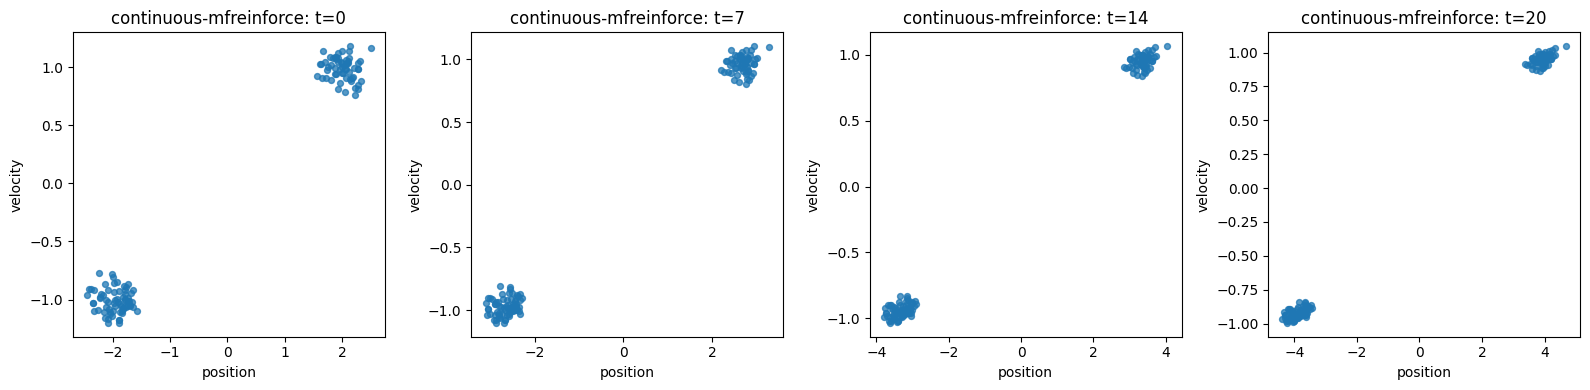

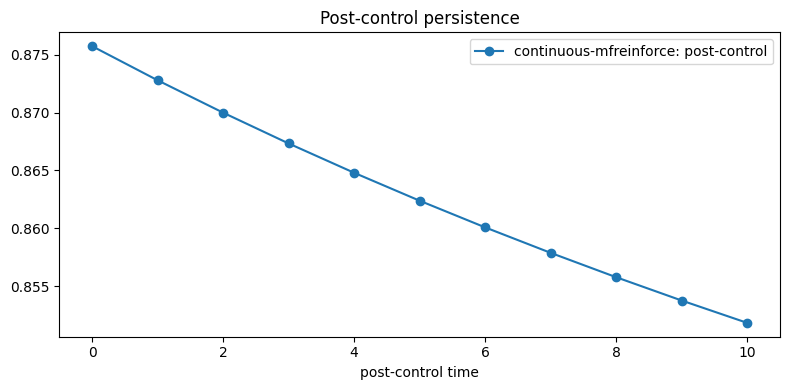

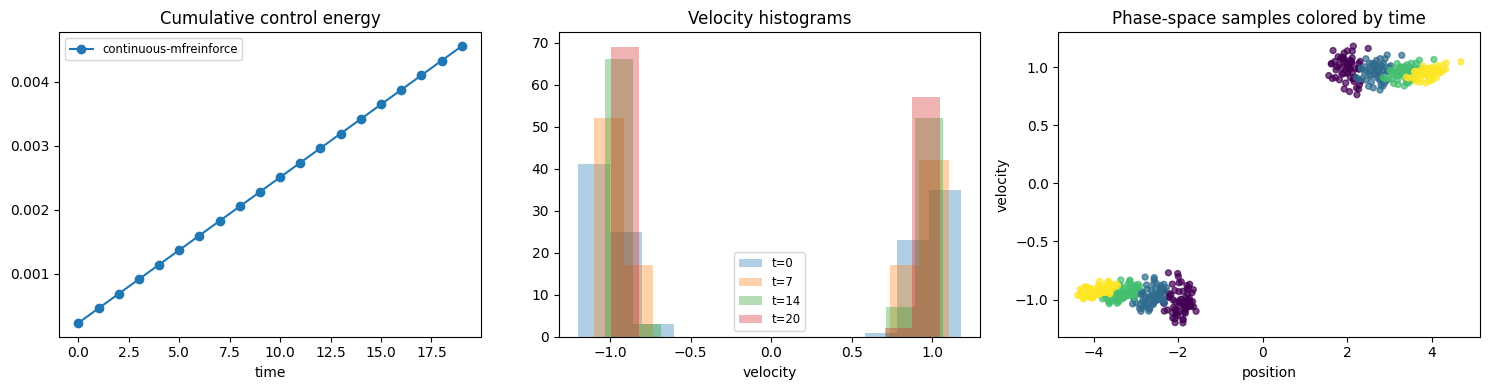

In [6]:
application = nh.load_application_data(bundle)
display(nh.reference_solution_table(ENV_NAME, application))
nh.plot_continuous_time_metrics(application, ENV_NAME)
nh.plot_continuous_policy_and_samples(application, ENV_NAME)
nh.plot_continuous_snapshots(application, ENV_NAME)
nh.plot_continuous_application_details(application, ENV_NAME)

## Universal Diagnostics

Goal: validate the estimator chain before interpreting optimization performance.

The perturbation plots measure empirical geometry,

$$
d(M^\lambda,\mu),
$$

including quantile bands and local log-log slopes. The functional-law plots study

$$
\Gamma(M^\lambda)=(F_1(M^\lambda),\ldots,F_k(M^\lambda)),
\qquad
\frac{\Gamma(M^\lambda)-\Gamma(\mu)}{\lambda},
$$

which is the induced law of population signatures. The score plots check

$$
S_{t,\lambda}^\theta=\nabla_\theta\log q_{t,\lambda}^\theta(M_t),
\qquad \mathbb{E}[S_{t,\lambda}^\theta]\approx 0,
$$

and the gradient plots report bias, variance, MSE, norm ratio, and cosine agreement for an estimator $\widehat g$ against an oracle or reference gradient $g$:

$$
\operatorname{MSE}=\mathbb{E}\|\widehat g-g\|_2^2,
\qquad
\cos(\widehat g,g)=\frac{\widehat g\cdot g}{\|\widehat g\|_2\|g\|_2}.
$$

The sensitivity plots track errors in $D_t=\partial_\theta\Gamma(\mu_t^\theta)$, or in the finite-state case $D_t=\partial_\theta\mu_t^\theta$.

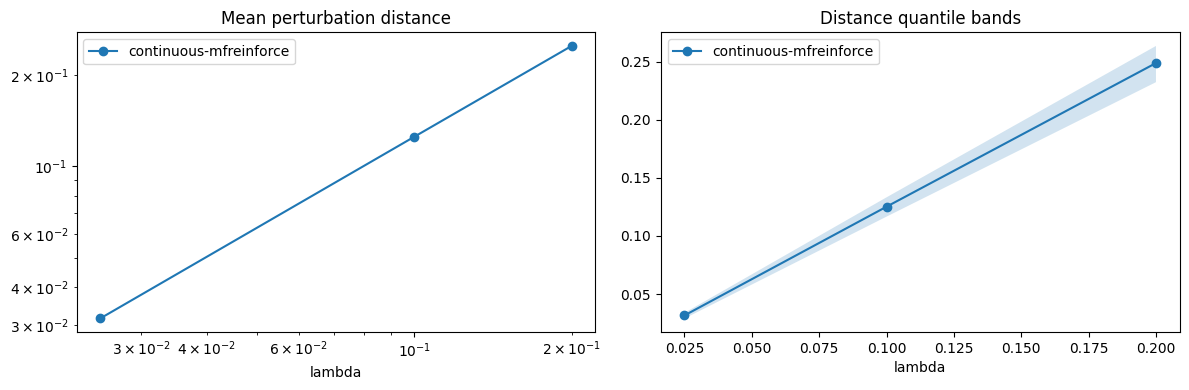

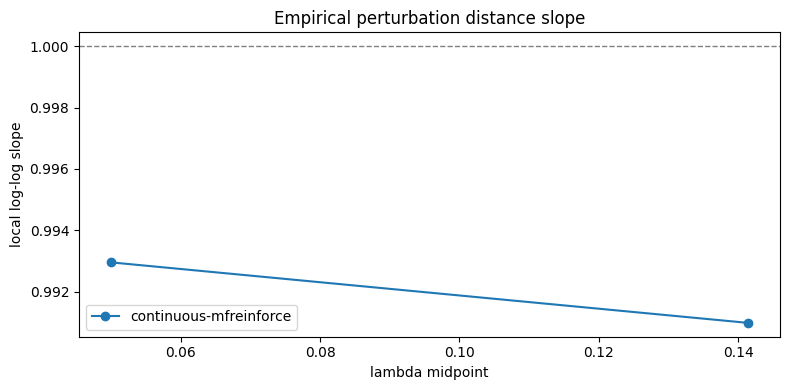

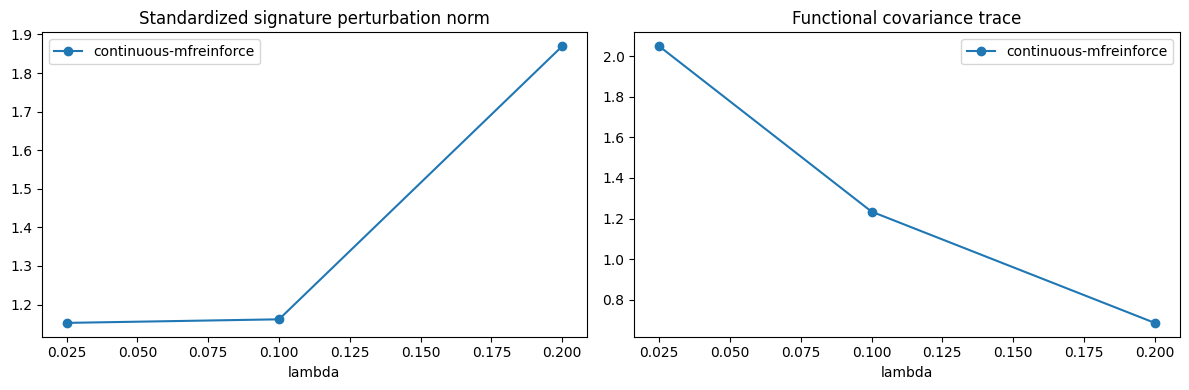

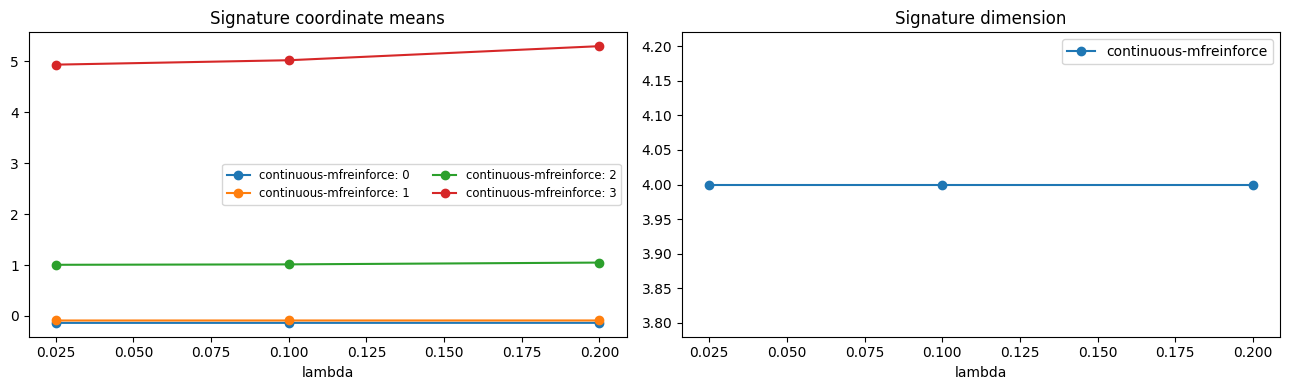

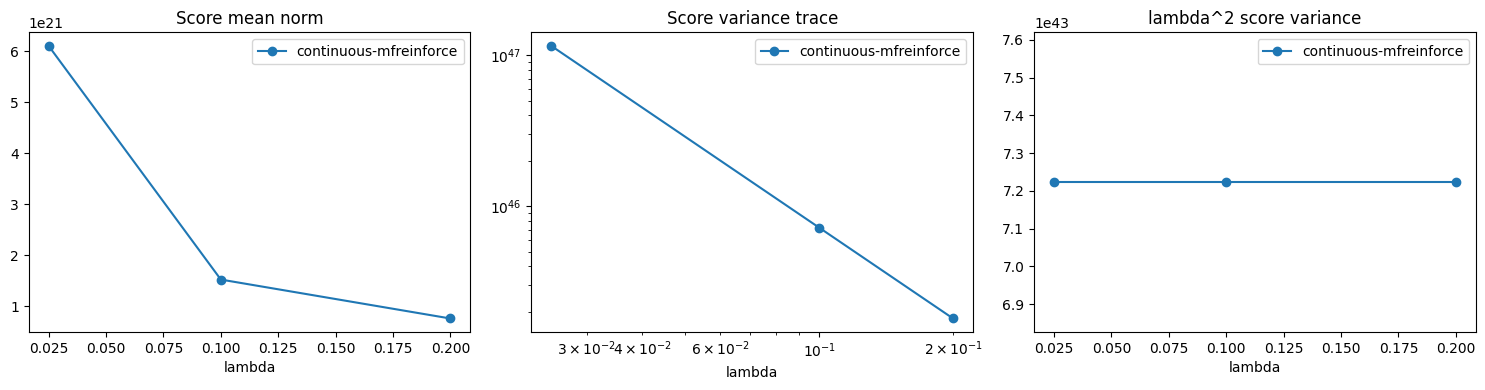

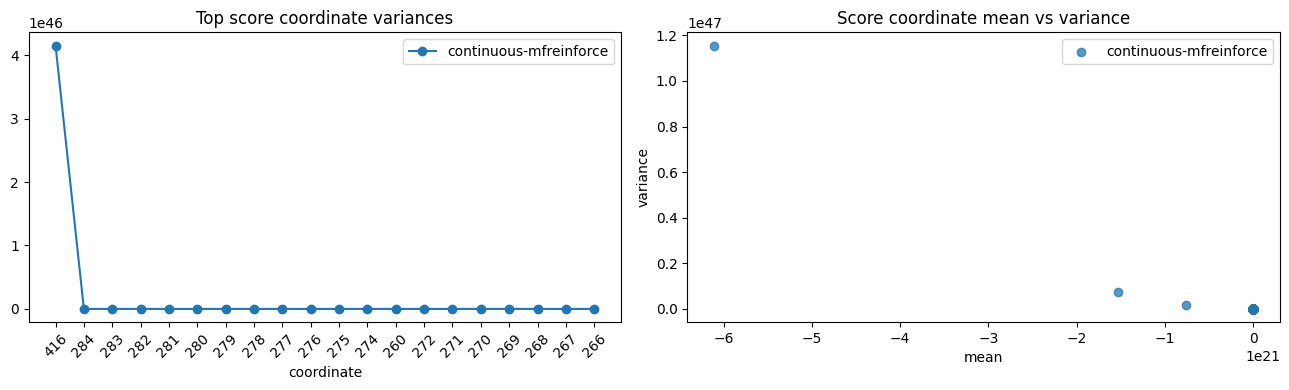

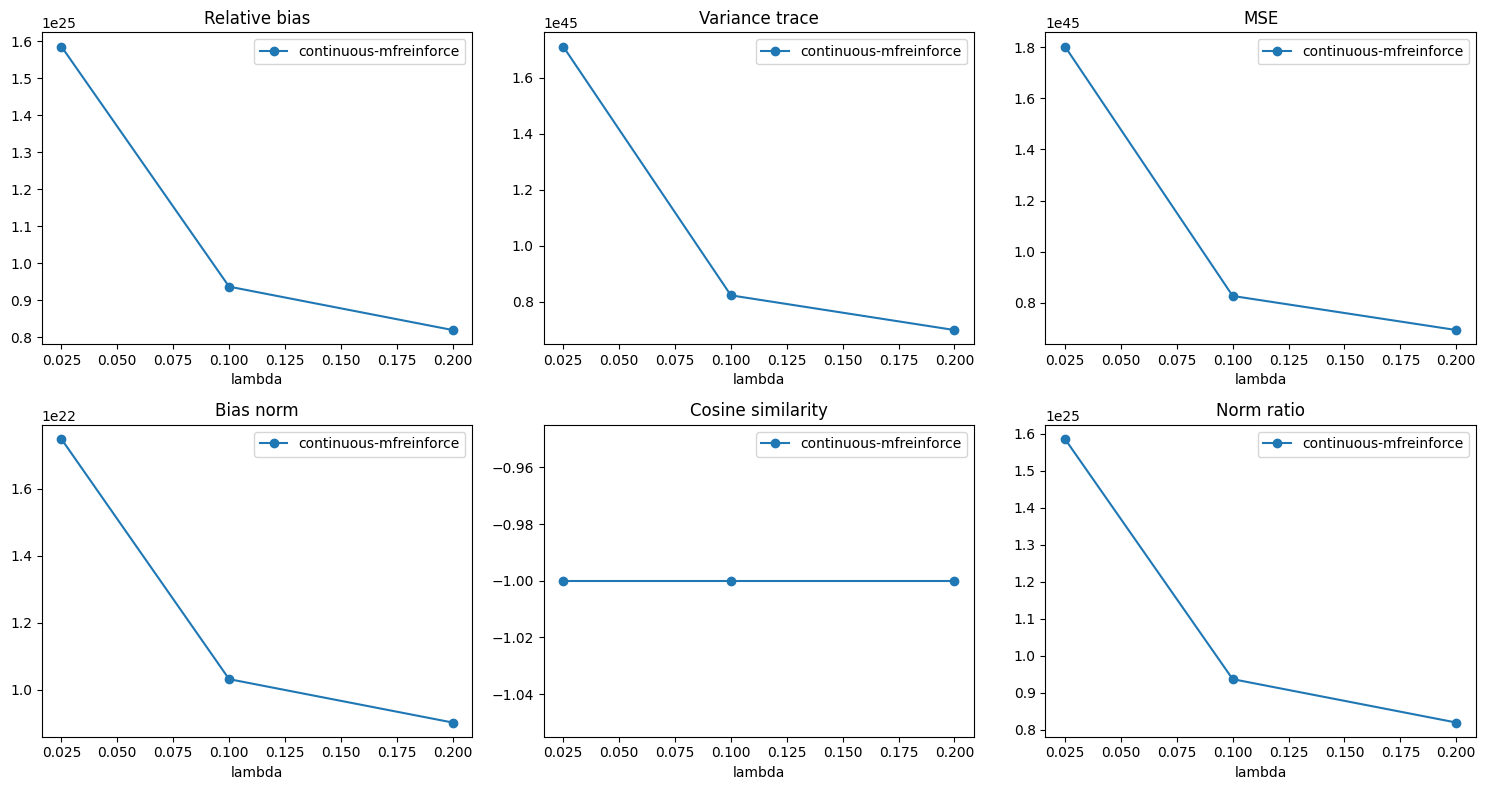

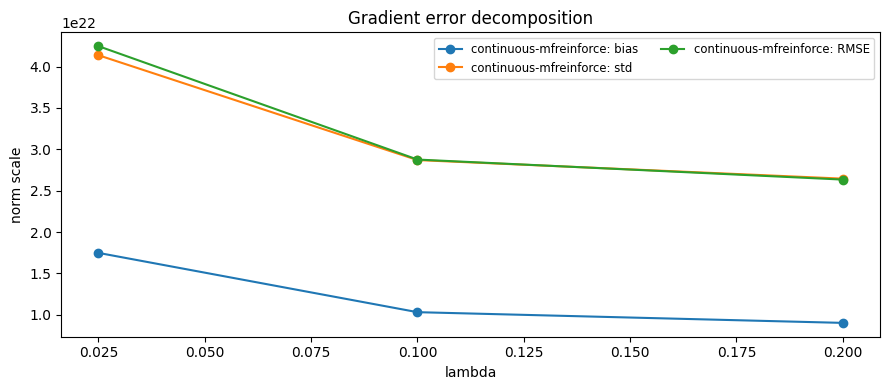

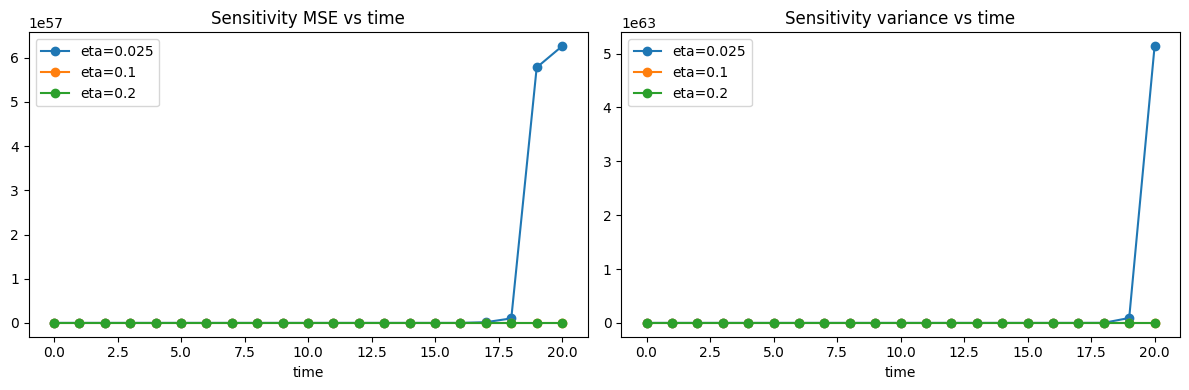

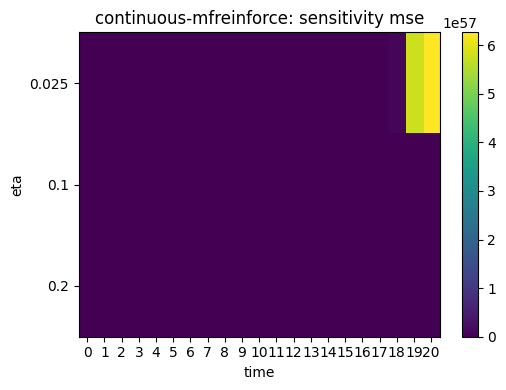

In [7]:
diagnostics = nh.load_diagnostic_data(bundle)
nh.plot_perturbation_geometry(diagnostics)
nh.plot_perturbation_slopes(diagnostics)
nh.plot_functional_law(diagnostics)
nh.plot_functional_signature_means(diagnostics)
nh.plot_score_validation(diagnostics)
nh.plot_score_coordinate_diagnostics(diagnostics)
nh.plot_gradient_validation(diagnostics)
nh.plot_gradient_error_decomposition(diagnostics)
nh.plot_sensitivity_validation(diagnostics)
nh.plot_sensitivity_heatmap(diagnostics)

## Scaling, Budget, And Optimization Summaries

Goal: measure how estimator quality and optimization performance change with simulator budget, auxiliary budget, horizon, and training time.

The budget heatmap varies main and auxiliary samples $(B,n)$ under the approximate cost model

$$
C\approx C_{main}B+C_{aux}n.
$$

The horizon plot studies how gradient error changes with $T$, and the optimization plots compare objective or cost gaps against iteration count, runtime, and simulator-call budget.

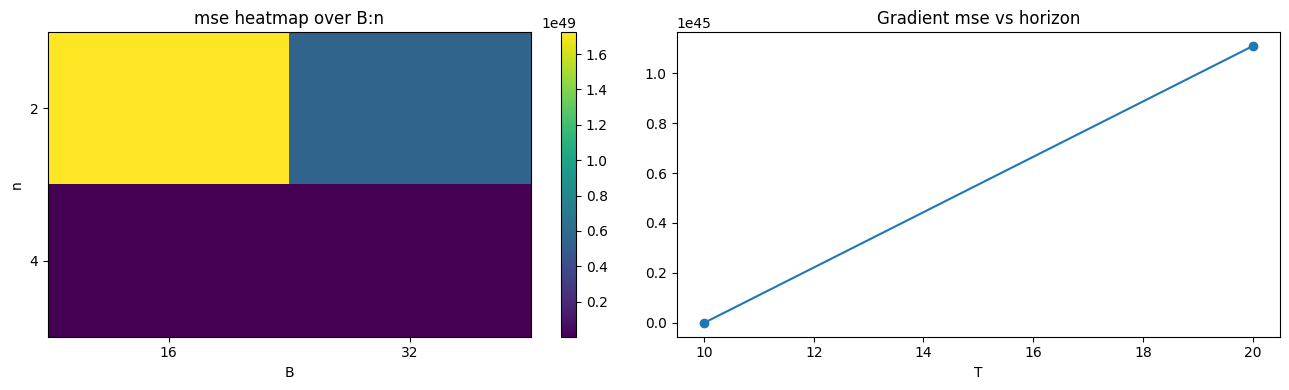

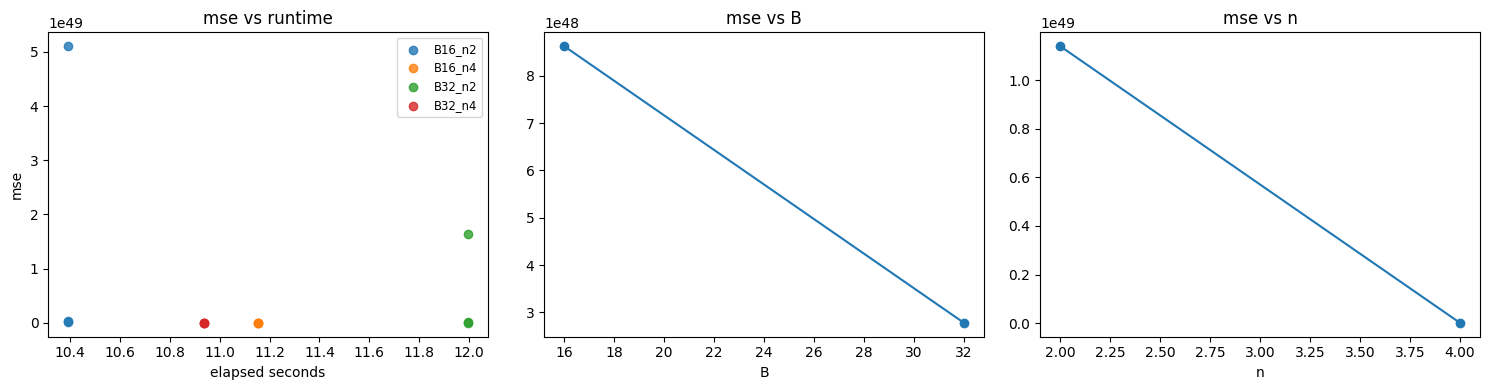

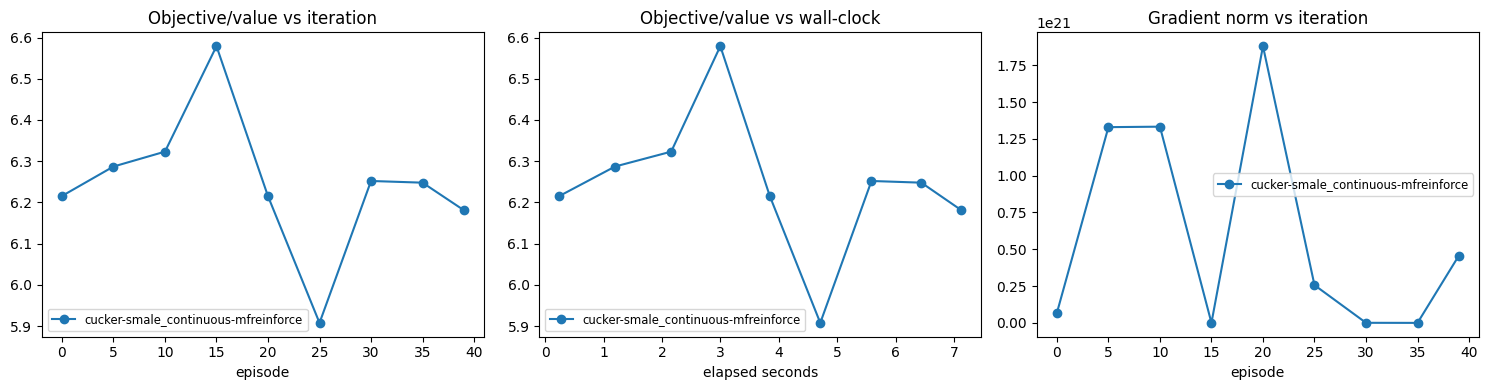

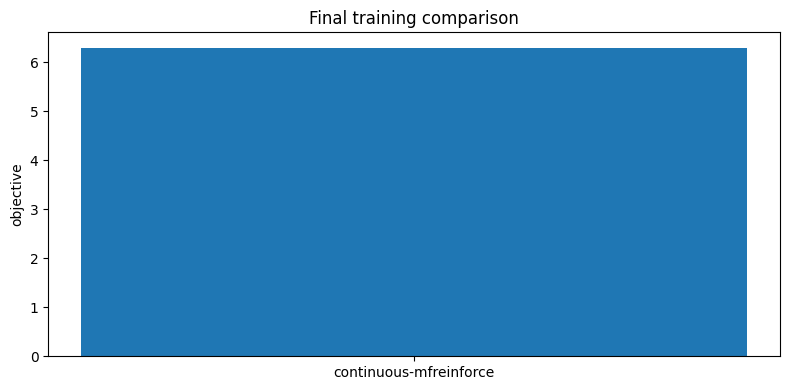

In [8]:
studies = nh.load_study_data(bundle)
grid_metrics = nh.load_study_grid_metrics(bundle)
optimization_history = nh.load_optimization_history(bundle)
nh.plot_budget_and_horizon(studies)
nh.plot_budget_pareto(studies, grid_metrics)
nh.plot_optimization_history(optimization_history)
nh.plot_optimization_summary(studies)

## Raw Tables For Custom Figures

Goal: expose the underlying CSV/JSON artifacts used by the plots so paper figures can be restyled or recomputed without rerunning training.

These tables are not new estimators. They are the saved values for population flows, policies, diagnostics, study grids, histories, and final metrics.

In [9]:
application[nh.CONTINUOUS_ALGORITHM]["time_metrics"].head(), diagnostics[nh.CONTINUOUS_ALGORITHM]["gradient"].head(), studies["budget"].head()

(       method  time  velocity_dispersion  spatial_diameter  control_energy
 0  controlled     0             1.004909          4.933981        0.000228
 1  controlled     1             0.991875          5.146442        0.000228
 2  controlled     2             0.980168          5.357464        0.000228
 3  controlled     3             0.969592          5.567157        0.000228
 4  controlled     4             0.959993          5.775621        0.000228,
    lambda  replications  estimate_norm  variance_trace  \
 0   0.025             8   1.748168e+22    1.710837e+45   
 1   0.100             8   1.032105e+22    8.234866e+44   
 2   0.200             8   9.026976e+21    6.997277e+44   
 
    covariance_largest_eigenvalue  oracle_norm     bias_norm  relative_bias  \
 0                   1.710837e+45     0.001102  1.748168e+22   1.585786e+25   
 1                   8.234866e+44     0.001102  1.032105e+22   9.362363e+24   
 2                   6.997277e+44     0.001102  9.026976e+21   8.188